# Build your own transient classifier, from zero

### ZTF Summer School — the complete machine-learning tutorial

This notebook assumes **no prior machine-learning knowledge**. By the end you
will have built, from raw telescope data, the full architecture of **FLARE** —
a production classifier for ZTF transients — and you will understand *why*
every piece exists:

1. The problem: what is in the sky? (data)
2. From light curves to numbers (features)
3. The golden rule: train / validation / test
4. A first model — and how it fools you (overfitting)
5. Gradient boosting: a team of weak learners
6. Knowing when to stop (early stopping, on validation)
7. The accuracy trap (class imbalance)
8. The final exam (the test set — touched once)
9. Honest probabilities (calibration and conformal prediction)
10. What you just built is FLARE

Requirements: the `flare` package (for data loading and feature extraction) and
standard scientific Python. Set `FLARE_DATA` to the `photo_events` directory.

In [1]:
import os, sys, warnings, time
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "../..")
from flare import BROAD_CLASSES
from flare import data as D
from flare.taxonomy import ID2BROAD_ID

DATA_DIR = os.environ.get("FLARE_DATA",
    "/work/hdd/bcrv/ffontinelenunes/data/AppleCider/photo_events")
D.DATA_DIR = __import__("pathlib").Path(DATA_DIR)

CLASS_COLOR = {"SNI": "#0072B2", "SNII": "#E69F00", "CV": "#009E73",
               "AGN": "#CC79A7", "TDE": "#D55E00"}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
print("Setup OK")

Setup OK


## 1. The problem

Robotic telescopes photograph the sky every night and detect things that
*change*: exploding stars, feeding black holes, stellar cannibals. Each object
comes to us as a **light curve** — brightness measured at irregular times in
two filters (g = green, r = red). A human expert can often tell what an object
is from its light curve. Our goal is to teach a computer the same skill.

Formally: we want a function that maps *light curve* $\to$ *class*, where class
is one of **SNI, SNII, CV, AGN, TDE**. Machine learning builds this function
from **examples** — thousands of light curves whose true class we already know
from spectroscopy.

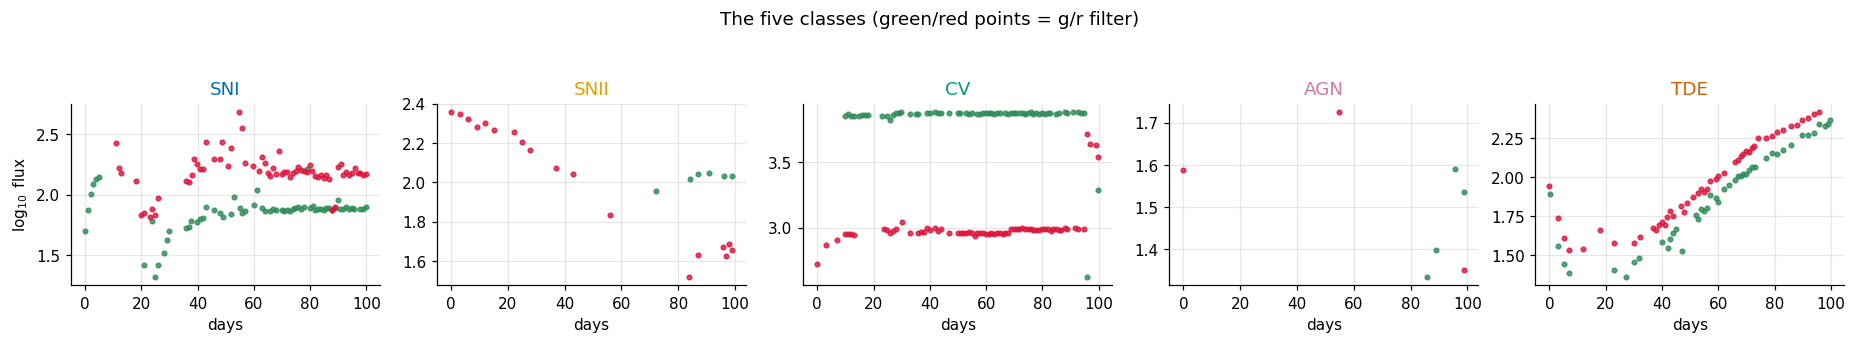

In [2]:
# Look at the raw material: one labelled example per class
manifest = D.load_manifest("train")
manifest["broad"] = manifest["label"].map(lambda x: BROAD_CLASSES[ID2BROAD_ID[int(x)]])

fig, axes = plt.subplots(1, 5, figsize=(17, 2.9))
for ax, cls in zip(axes, BROAD_CLASSES):
    row = manifest[manifest.broad == cls].nlargest(1, "n_events").iloc[0]
    bands = D.reconstruct_bands(D.load_events(row.filepath))
    for name, colr in [("g", "seagreen"), ("r", "crimson")]:
        if name in bands:
            ax.plot(bands[name].t, bands[name].logflux, "o", ms=3, color=colr, alpha=0.8)
    ax.set_title(cls, color=CLASS_COLOR[cls])
    ax.set_xlabel("days")
axes[0].set_ylabel(r"$\log_{10}$ flux")
plt.suptitle("The five classes (green/red points = g/r filter)", y=1.06)
plt.tight_layout(); plt.show()

## 2. From light curves to numbers

A computer cannot look at a plot. Light curves also have different lengths and
irregular sampling — awkward inputs for most algorithms. The classical solution
is **feature engineering**: summarise every light curve by the *same fixed list
of numbers*, chosen to capture physics. Examples:

- `g_r_mean` — average colour: is the object blue or red?
- `g_eta_e` — smoothness: does it evolve steadily or flicker?
- `g_bazin_fall_time` — how many days does it take to fade?
- `g_bazin_reduced_chi2` — does an "explosion-shaped" curve fit it at all?

FLARE's extractor computes **160** such features per object. Extracting them for
the whole dataset takes under a minute.

In [3]:
from multiprocessing import Pool
from flare.features import extract_object_features

def _worker(args):
    fp, lab = args
    try:
        f = extract_object_features(fp)
    except Exception:
        f = {}
    f["label"] = lab
    return f

def load_split(split):
    mf = D.load_manifest(split)
    kept, _ = D.filter_manifest_quality(mf)          # basic data-quality cuts
    with Pool(8) as p:
        rows = p.map(_worker, list(zip(kept.filepath, kept.label)), chunksize=64)
    df = pd.DataFrame(rows)
    y = df["label"].map(lambda x: ID2BROAD_ID[int(x)]).values
    X = df.drop(columns=["label"])
    return X[sorted(X.columns)], y

t0 = time.time()
X_train, y_train = load_split("train")
X_val,   y_val   = load_split("val")
X_test,  y_test  = load_split("test")
print(f"features extracted in {time.time()-t0:.0f}s")
for name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    counts = {BROAD_CLASSES[c]: int((y == c).sum()) for c in range(5)}
    print(f"  {name:5s}: {len(y):5d} objects  {counts}")

E20260727 15:13:18.920302 325130 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 15:13:18.920548 325130 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260727 15:13:19.477471 325140 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260727 15:13:20.040625 325112 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 15:13:20.173089 325112 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260727 15:13:20.569321 325129 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 15:13:20.758127 325140 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260727 15:13:20.974079 325140 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


...

E20260727 15:15:08.942157 381776 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 15:15:09.001085 381799 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 15:15:09.005935 381798 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 15:15:09.023193 381787 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 15:15:09.031316 381798 trust_region_minimizer.cc:121] Terminating: Residual and Jacobian evaluation failed.


E20260727 15:17:11.989629 454363 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 15:17:12.030728 454321 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 15:17:12.054287 454358 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 15:17:12.083212 454333 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 15:17:12.139170 454321 polynomial.cc:235] Failed to extract eigenvalues from companion matrix.
W20260727 15:17:12.139266 454321 polynomial.cc:305] Unable to find the critical points of the interpolating polynomial.
E20260727 15:17:12.139395 454321 polynomial.cc:235] Failed to extract eigenvalues from companion matrix.
W20260727 15:17:12.139412 454321 polynomial.cc:305] Unable to find the critical points of the interpolating polynomial.


E20260727 15:17:12.215792 454333 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 15:17:12.310683 454333 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 15:17:12.336917 454290 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 15:17:12.397125 454358 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 15:17:12.397761 454358 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260727 15:17:12.517534 454290 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 15:17:12.521624 454363 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 15:17:12.541206 454349 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 15:17:12.559535 454333 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 15:17:12.593075 454379 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 15:17:12.595530 454333 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 15:17:12.604094 454321 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 15:17:12.632814 454363 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


features extracted in 790s
  train:  9217 objects  {'SNI': 4081, 'SNII': 1051, 'CV': 346, 'AGN': 3692, 'TDE': 47}
  val  :  1991 objects  {'SNI': 882, 'SNII': 229, 'CV': 70, 'AGN': 801, 'TDE': 9}
  test :  1979 objects  {'SNI': 886, 'SNII': 219, 'CV': 91, 'AGN': 774, 'TDE': 9}


## 3. The golden rule: train / validation / test

We just loaded **three separate sets of objects**. This split is the single
most important idea in applied machine learning:

| set | role | analogy |
|---|---|---|
| **train** (~9,200) | the model learns from these | homework problems |
| **validation** (~2,000) | we compare models / tune settings on these | mock exam |
| **test** (~2,000) | evaluated **once**, at the very end | the final exam |

Why three? Because a model can *memorise* its homework. Its score on data it
has seen tells you nothing about how it will do on tomorrow's sky. And if you
tune your model many times against the same exam, you slowly memorise *that*
too — which is why the mock exam (validation) and the final exam (test) must
be different objects. **Nothing we do from here on may touch the test set until
Section 8.** Every ZTF object lives in exactly one of the three sets.

## 4. A first model — and how it fools you

The simplest interpretable model is a **decision tree**: a flow chart of
yes/no questions about the features ("is `g_r_mean` < $-0.2$? then ... ").
Let's watch one learn on just two features so we can see its decisions.

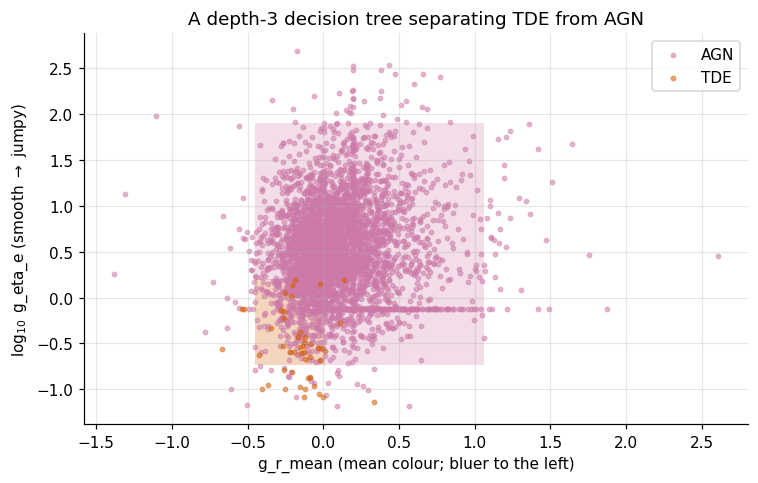

In [4]:
from sklearn.tree import DecisionTreeClassifier

two = ["g_r_mean", "g_eta_e"]
Xt2 = X_train[two].fillna(X_train[two].median())
Xv2 = X_val[two].fillna(X_train[two].median())     # note: TRAIN medians!
mask = np.isin(y_train, [BROAD_CLASSES.index("TDE"), BROAD_CLASSES.index("AGN")])
maskv = np.isin(y_val, [BROAD_CLASSES.index("TDE"), BROAD_CLASSES.index("AGN")])

tree = DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=0)
tree.fit(Xt2[mask], y_train[mask])

# paint its decisions on the plane (TDE vs AGN)
gx = np.linspace(*np.nanpercentile(Xt2.iloc[:, 0][mask], [1, 99]), 300)
gy = np.linspace(*np.nanpercentile(np.log10(Xt2.iloc[:, 1][mask].clip(1e-4)), [1, 99]), 300)
GX, GY = np.meshgrid(gx, gy)
Z = tree.predict(np.c_[GX.ravel(), 10**GY.ravel()]).reshape(GX.shape)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.contourf(GX, GY, Z == BROAD_CLASSES.index("TDE"), levels=1,
            colors=["#CC79A7", "#D55E00"], alpha=0.25)
for cls in ["AGN", "TDE"]:
    c = BROAD_CLASSES.index(cls)
    m = mask & (y_train == c)
    ax.scatter(Xt2[m].iloc[:, 0], np.log10(Xt2[m].iloc[:, 1].clip(1e-4)),
               s=8, alpha=0.5, color=CLASS_COLOR[cls], label=cls)
ax.set_xlabel("g_r_mean (mean colour; bluer to the left)")
ax.set_ylabel(r"$\log_{10}$ g_eta_e (smooth $\to$ jumpy)")
ax.set_title("A depth-3 decision tree separating TDE from AGN")
ax.legend()
plt.tight_layout(); plt.show()

Straight cuts, exactly like an astronomer's selection box — learned from data.

Now the trap. A deeper tree can carve ever finer boxes, until it draws a box
around *every individual training object*. Watch what happens to the two
accuracies as we let the tree grow (all 160 features, all 5 classes now):

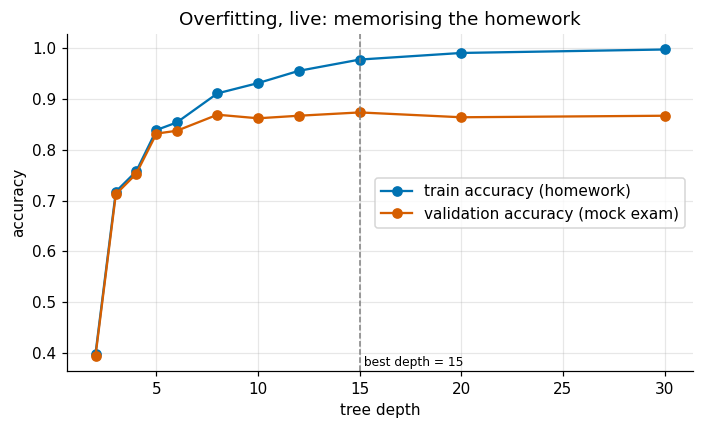

In [5]:
med = X_train.median()
Xt = X_train.fillna(med); Xv = X_val.fillna(med)

depths = [2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 30]
acc_tr, acc_va = [], []
for d in depths:
    t = DecisionTreeClassifier(max_depth=d, class_weight="balanced",
                               random_state=0).fit(Xt, y_train)
    acc_tr.append(t.score(Xt, y_train))
    acc_va.append(t.score(Xv, y_val))

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(depths, acc_tr, "-o", color="#0072B2", label="train accuracy (homework)")
ax.plot(depths, acc_va, "-o", color="#D55E00", label="validation accuracy (mock exam)")
best = depths[int(np.argmax(acc_va))]
ax.axvline(best, ls="--", color="0.5", lw=1)
ax.text(best, ax.get_ylim()[0] + 0.01, f" best depth = {best}", fontsize=8)
ax.set_xlabel("tree depth"); ax.set_ylabel("accuracy")
ax.set_title("Overfitting, live: memorising the homework")
ax.legend()
plt.tight_layout(); plt.show()

The blue curve climbs towards 100%: the deep tree memorises its homework
perfectly. The orange curve — the only one that matters — rises, then stalls
and *falls*. That gap is **overfitting**, and it is why the validation set
exists: it is the honest voice telling us when to stop believing the training
score. Note that even the humble missing-value fill used the *train* medians
only — using validation or test statistics anywhere in training is called
**leakage**, and it silently inflates every score downstream.

## 5. Gradient boosting: a team of weak learners

One tree is limited — a single flow chart. **Gradient boosting** builds an
army of *small* trees, sequentially, where each new tree is trained to correct
the errors of the team so far:

$$F(x) \;=\; f_1(x) + f_2(x) + f_3(x) + \dots$$

Tree $f_{m+1}$ fits the *gradient of the loss* of the current team $F_m$ —
loosely, "the direction in which the current predictions are most wrong".
Hundreds of shallow trees, each fixing the last one's mistakes, add up to a
powerful and fast model. We use the LightGBM implementation.

## 6. Knowing when to stop

How many trees? Same overfitting logic, same answer: watch the validation set,
and stop when it stops improving — **early stopping**.

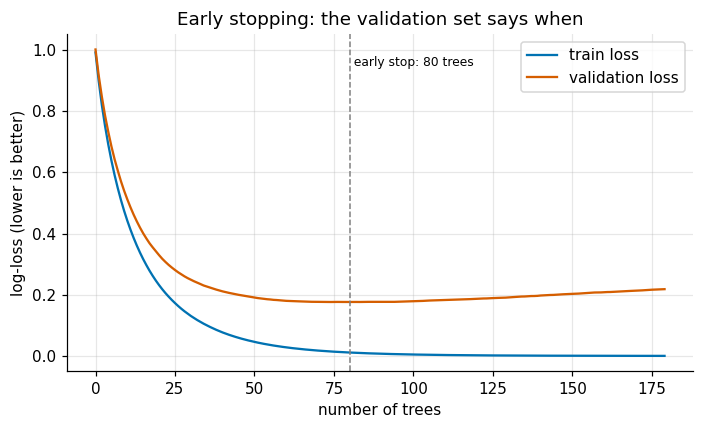

In [6]:
import lightgbm as lgb

params = {"objective": "multiclass", "num_class": 5, "metric": "multi_logloss",
          "learning_rate": 0.05, "num_leaves": 64, "verbosity": -1, "seed": 42}

dtrain = lgb.Dataset(X_train, label=y_train)
dval = lgb.Dataset(X_val, label=y_val, reference=dtrain)
evals = {}
model = lgb.train(params, dtrain, num_boost_round=2000,
                  valid_sets=[dtrain, dval], valid_names=["train", "val"],
                  callbacks=[lgb.early_stopping(100, verbose=False),
                             lgb.record_evaluation(evals)])

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(evals["train"]["multi_logloss"], color="#0072B2", label="train loss")
ax.plot(evals["val"]["multi_logloss"], color="#D55E00", label="validation loss")
ax.axvline(model.best_iteration, ls="--", color="0.5", lw=1)
ax.text(model.best_iteration, ax.get_ylim()[1]*0.9,
        f" early stop: {model.best_iteration} trees", fontsize=8)
ax.set_xlabel("number of trees"); ax.set_ylabel("log-loss (lower is better)")
ax.set_title("Early stopping: the validation set says when")
ax.legend()
plt.tight_layout(); plt.show()

Train loss falls forever (memorisation again); validation loss bottoms out and
would slowly rise. We keep the team exactly at the marked size.

## 7. The accuracy trap

Before the final exam, one more honesty check. Our classes are wildly
imbalanced — about 44% of objects are SNI and only 0.5% are TDEs. A model that
*never predicts TDE at all* can still post a high accuracy. Let's compare our
model against the dumbest possible baseline, and look **per class**:

In [7]:
from sklearn.metrics import balanced_accuracy_score

baseline = np.full(len(y_val), np.bincount(y_train).argmax())   # always SNI
pred_val = model.predict(X_val, num_iteration=model.best_iteration).argmax(1)

print(f"{'':22s} accuracy   balanced accuracy")
print(f"always-predict-SNI    {np.mean(baseline == y_val):.3f}      "
      f"{balanced_accuracy_score(y_val, baseline):.3f}")
print(f"our model             {np.mean(pred_val == y_val):.3f}      "
      f"{balanced_accuracy_score(y_val, pred_val):.3f}")

print("\nper-class recall (our model, validation):")
for c, name in enumerate(BROAD_CLASSES):
    m = y_val == c
    print(f"  {name:5s} (n={m.sum():4d}): {(pred_val[m] == c).mean():.2f}")

                       accuracy   balanced accuracy
always-predict-SNI    0.443      0.200
our model             0.947      0.804

per-class recall (our model, validation):
  SNI   (n= 882): 0.98
  SNII  (n= 229): 0.76
  CV    (n=  70): 0.86
  AGN   (n= 801): 0.98
  TDE   (n=   9): 0.44


Accuracy alone hides the rare classes; **balanced accuracy** (the average of
per-class recalls) exposes them. To help the minorities, we re-weight the loss
so that mistakes on rare classes cost more — FLARE uses weights
$w_c \propto (1/n_c)^{\beta}$, with the strength $\beta$ chosen, as always, on
validation:

In [8]:
def train_weighted(beta):
    counts = np.bincount(y_train, minlength=5).astype(float)
    w = ((len(y_train) / (5 * counts)) ** beta)[y_train]
    dtr = lgb.Dataset(X_train, label=y_train, weight=w)
    dva = lgb.Dataset(X_val, label=y_val, reference=dtr)
    return lgb.train(params, dtr, num_boost_round=2000, valid_sets=[dva],
                     callbacks=[lgb.early_stopping(100, verbose=False)])

print("beta   val accuracy   val balanced acc   val TDE recall")
results = {}
for beta in [0.0, 0.5, 0.9]:
    m = train_weighted(beta)
    p = m.predict(X_val, num_iteration=m.best_iteration).argmax(1)
    tde = BROAD_CLASSES.index("TDE")
    results[beta] = m
    print(f"{beta:.1f}    {np.mean(p == y_val):.3f}          "
          f"{balanced_accuracy_score(y_val, p):.3f}              "
          f"{(p[y_val == tde] == tde).mean():.2f}")

final_model = results[0.9]      # chosen on validation — before ever seeing test
print(f"\nchosen model: beta=0.9, {final_model.num_trees()} trees")

beta   val accuracy   val balanced acc   val TDE recall


0.0    0.947          0.804              0.44


0.5    0.945          0.811              0.44


0.9    0.944          0.810              0.44

chosen model: beta=0.9, 445 trees


## 8. The final exam

We made every choice — features, depth intuition, tree count, class weights —
using train and validation only. Now, once, we open the test set.

TEST accuracy          : 0.950
TEST balanced accuracy : 0.796
TEST macro F1          : 0.814


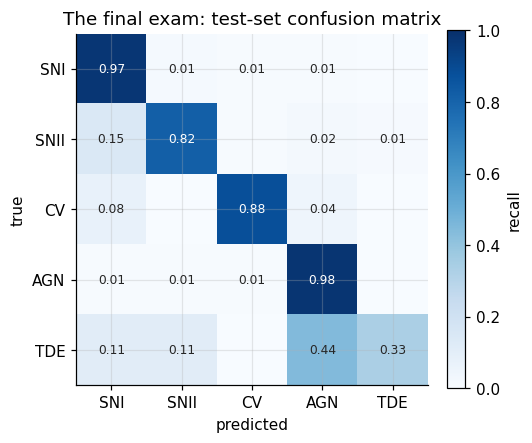

In [9]:
from sklearn.metrics import confusion_matrix, f1_score

P_test = final_model.predict(X_test, num_iteration=final_model.best_iteration)
pred_test = P_test.argmax(1)

print(f"TEST accuracy          : {np.mean(pred_test == y_test):.3f}")
print(f"TEST balanced accuracy : {balanced_accuracy_score(y_test, pred_test):.3f}")
print(f"TEST macro F1          : {f1_score(y_test, pred_test, average='macro'):.3f}")

cm = confusion_matrix(y_test, pred_test, labels=range(5))
cmn = cm / cm.sum(1, keepdims=True)
fig, ax = plt.subplots(figsize=(4.8, 4.2))
im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(5)); ax.set_yticks(range(5))
ax.set_xticklabels(BROAD_CLASSES); ax.set_yticklabels(BROAD_CLASSES)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
for i in range(5):
    for j in range(5):
        if cmn[i, j] >= 0.005:
            ax.text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if cmn[i,j] > 0.55 else "0.15")
ax.set_title("The final exam: test-set confusion matrix")
fig.colorbar(im, fraction=0.046, label="recall")
plt.tight_layout(); plt.show()

You built this in an afternoon, and it is within about a point of the tuned
production model (the released FLARE weights reach 0.957 test accuracy — the
remaining gap is 100 trials of automated hyperparameter search doing, on
validation, exactly what you did by hand for depth, trees and $\beta$).

## 9. Honest probabilities

A production model does not just answer — it says *how sure* it is, and that
number must mean something. Two tools finish the architecture:

- **Calibration**: when the model says "80%", it should be right ~80% of the
  time. Boosted trees trained on log-loss are naturally close to calibrated.
- **Conformal prediction**: turns probabilities into a *set* of classes that
  contains the truth with guaranteed probability (e.g.\ 90%), per class. The
  quantiles are calibrated on — of course — the validation set.

In [10]:
from flare import conformal

qhat = conformal.calibrate(
    final_model.predict(X_val, num_iteration=final_model.best_iteration),
    y_val, alpha=0.10)
sets = conformal.prediction_sets(P_test, qhat)
rep = conformal.coverage_report(sets, y_test)

print("class  n     coverage  avg set size   (target: 0.90)")
for k, v in rep.items():
    print(f"{k:9s} {v['n']:5d}   {v['coverage']:.3f}     {v['avg_set_size']:.2f}")

class  n     coverage  avg set size   (target: 0.90)
SNI         886   0.897     1.05
SNII        219   0.936     1.13
CV           91   0.868     1.08
AGN         774   0.919     1.00
TDE           9   0.889     1.33
marginal   1979   0.909     1.04


Every class — including the nine test TDEs — gets its guaranteed coverage,
without discarding a single object.

## 10. What you just built is FLARE

```
light curve  ->  160 physics features  ->  gradient-boosted trees  ->  probabilities
 (g,r,i)         (Section 2)              (Sections 5-7:               (Section 9:
                                           early stopping on val,       calibrated +
                                           class weights)               conformal sets)
```

Every design decision traced back to one principle: **let the validation set
decide, and keep the test set sacred.** The production package
(`pip install -e ../..`, `FlareClassifier.from_pretrained()`) is this exact
architecture with automated tuning — plus the anomaly-detection layer, which is
the subject of the next notebook (`tutorial.ipynb`).

### Exercises

1. **Leakage experiment.** Re-run Section 4 filling missing values with the
   *combined* train+validation medians. How much does the validation accuracy
   change? Why is even a small change dangerous?
2. **Feature ablation.** Retrain the final model without the 16 colour
   features. Which class suffers most, and does that match the physics?
3. **Your own feature.** Add one new feature to the extraction (e.g.\ the
   time between the g and r maxima) and measure whether validation balanced
   accuracy improves.
4. **Beta sweep.** Extend Section 7 to $\beta \in \{0, 0.25, 0.5, 0.75, 1.0\}$
   and plot the accuracy / TDE-recall trade-off. Where would you operate a
   spectrograph-allocation system, and why?